# Verify polytope functions: C++ (Microstructure/Sample_Pn_UU) vs. pure Python (calculate_polytopes_python)

Runs both implementations on the same 2D binary image and plots the resulting `p3h`, `p3v`, `p4`, `p6`, and `L` curves on top of each other for a visual sanity check, alongside the numeric max-diff table.

**Requirements to run the C++ side:**
- `cpp_poly/512/Cpp_source/Polytope/Sample_Pn_UU` must be a working, statically-linked build (see `compare_polytopes.py` at the repo root for background - the original dynamically-linked build needs MinGW runtime DLLs that may not be on PATH).
- Run this notebook with a kernel from the `gui_micro` conda env (needs `numpy`, `numba`, `pandas`, `matplotlib`, `tifffile`; install `ipykernel` in that env if it doesn't show up as a kernel choice: `pip install ipykernel` then select the env's interpreter in VS Code / `python -m ipykernel install --user --name gui_micro`).

In [2]:
import sys
sys.path.insert(0, "..")  # repo root, so `from src.micro_gui...` resolves the same way calculate_SMD.py does

import os
import numpy as np
import matplotlib.pyplot as plt
import tifffile

from src.micro_gui.analysis.smds import calculate_polytopes, calculate_polytopes_python

## Load the test image

Image shape: (512, 512), foreground (pore) fraction: 0.2504


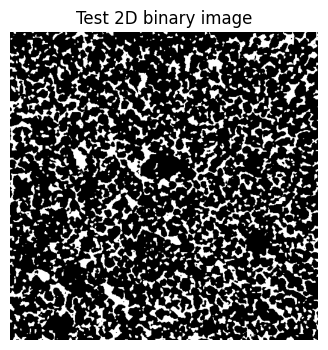

In [3]:
IMAGE_PATH = "../test_images/XCT_11.4um_binary0000.tif"

img = tifffile.imread(IMAGE_PATH).astype(np.uint8)
print(f"Image shape: {img.shape}, foreground (pore) fraction: {img.mean():.4f}")

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.title("Test 2D binary image")
plt.axis("off")
plt.show()

## Run the old C++-based method (`calculate_polytopes`)

This is the same function `calculate_SMD.py` uses - it writes `Mconfig.txt`, shells out to the compiled `Sample_Pn_UU` executable, and reads back the `Sobj*.txt`/`sobj*.txt` outputs.

In [4]:
POLYTOPES = ["p3h", "p3v", "p4", "p6", "L"]

par = {"name": "polytopes", "begx": 0, "begy": 0, "nsamp": img.shape[0], "edge_buffer": 0}

cpathPn = "../cpp_poly/512/Cpp_source/Polytope/"
runtimePn = "../cpp_poly/512/runtime/"
outputPn = "../cpp_poly/512/runtime/output/"

In [5]:
cpp_raw = {}
cpp_scaled = {}

for name in POLYTOPES:
    try:
        raw, scaled = calculate_polytopes(img, par, outputPn, cpathPn, runtimePn, polytope=name)
        cpp_raw[name] = raw
        cpp_scaled[name] = scaled
        print(f"{name}: cpp done")
    except Exception as e:
        print(f"{name}: CPP FAILED - {type(e).__name__}: {e}")

p3h: cpp done
p3v: cpp done
p4: cpp done
p6: cpp done
L: cpp done


## Run the new pure-Python/numba method (`calculate_polytopes_python`)

One call computes everything requested directly on the numpy array - no Mconfig.txt, no subprocess, no compiled executable.

In [6]:
py_raw, py_scaled = calculate_polytopes_python(img, polytopes=tuple(POLYTOPES))
print("python done:", list(py_raw.keys()))

python done: ['p3h', 'p3v', 'p4', 'p6', 'L']


## Numeric comparison table (raw Pn(r) curves)

In [7]:
print(f"{'polytope':10s} {'max_abs_diff':>14s} {'max_rel_diff':>14s} {'n_mismatch(>1e-4)':>20s}")
for name in POLYTOPES:
    if name not in cpp_raw:
        print(f"{name:10s}  (skipped - cpp run failed above)")
        continue
    ref = cpp_raw[name][:, 1]
    mine = py_raw[name][:, 1]
    diff = np.abs(mine - ref)
    rel = diff / np.maximum(np.abs(ref), 1e-12)
    n_mismatch = int(np.sum(diff > 1e-4))
    print(f"{name:10s} {diff.max():14.8f} {rel.max():14.8f} {n_mismatch:20d}")

polytope     max_abs_diff   max_rel_diff    n_mismatch(>1e-4)
p3h            0.00007551     0.00396041                    0
p3v            0.00009094     0.00581134                    0
p4             0.00005696     0.00785702                    0
p6             0.00003043     0.03342919                    0
L              0.00000050     0.05004009                    0


## Plot: raw Pn(r) curves, C++ vs. Python overlaid

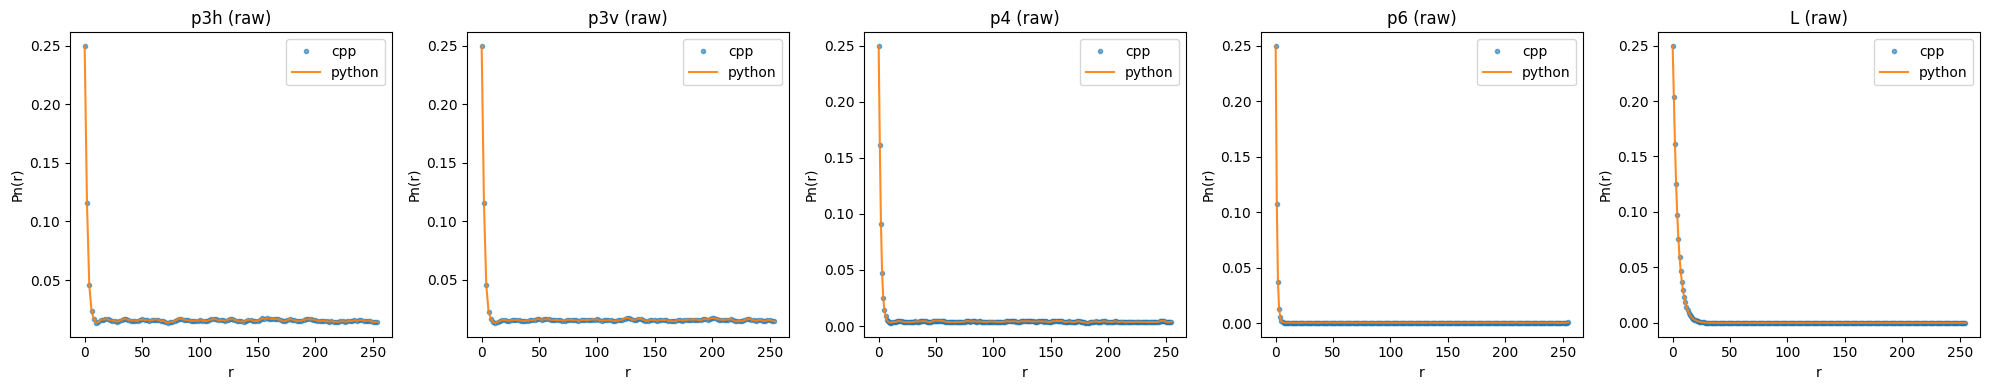

In [8]:
fig, axes = plt.subplots(1, len(POLYTOPES), figsize=(4 * len(POLYTOPES), 4), squeeze=False)
axes = axes[0]

for ax, name in zip(axes, POLYTOPES):
    if name in cpp_raw:
        if name in ["p3h", "p3v"]:
            ax.plot(cpp_raw[name][::2, 0], cpp_raw[name][::2, 1], "o", ms=3, alpha=0.6, label="cpp")
            ax.plot(py_raw[name][::2, 0], py_raw[name][::2, 1], "-", lw=1.5, alpha=0.9, label="python")
        else:
            ax.plot(cpp_raw[name][:, 0], cpp_raw[name][:, 1], "o", ms=3, alpha=0.6, label="cpp")
            ax.plot(py_raw[name][:, 0], py_raw[name][:, 1], "-", lw=1.5, alpha=0.9, label="python")
    ax.set_title(f"{name} (raw)")
    ax.set_xlabel("r")
    ax.set_ylabel("Pn(r)")
    ax.legend()

plt.tight_layout()
plt.show()

## Plot: scaled fn(r) curves, C++ vs. Python overlaid

(`fn` is the normalised companion curve - `polyfn_*` for P3H/P3V/P4/P6, and the S2-based `scal_autocov` for `L`, matching the original `Microstructure` class.)

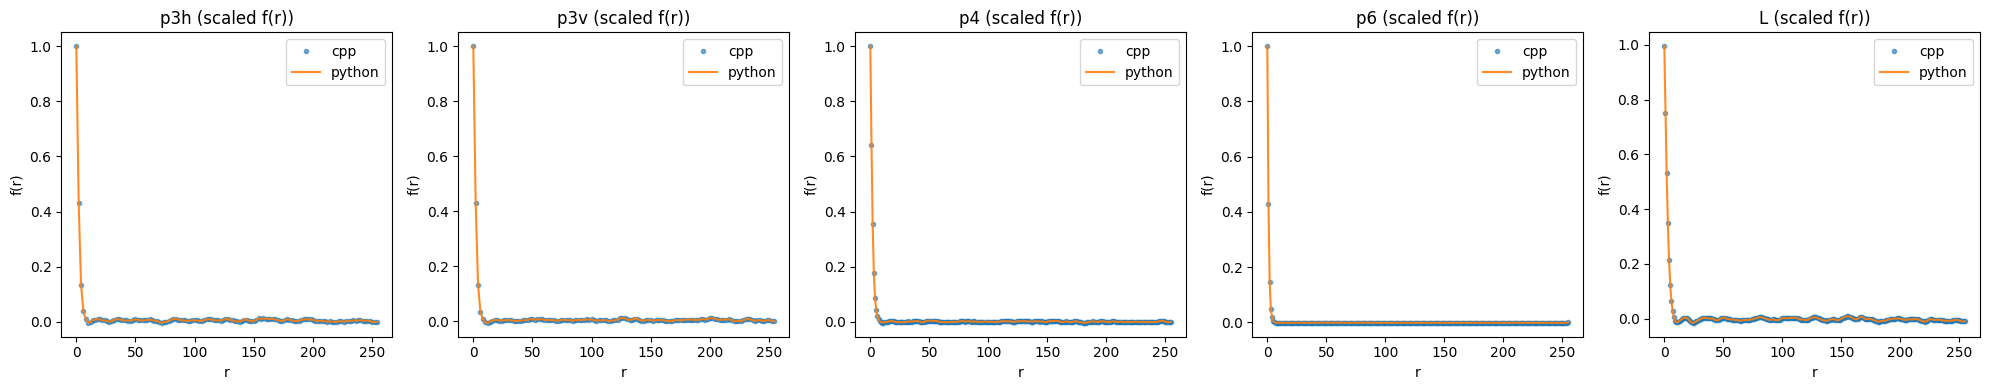

In [9]:
fig, axes = plt.subplots(1, len(POLYTOPES), figsize=(4 * len(POLYTOPES), 4), squeeze=False)
axes = axes[0]

for ax, name in zip(axes, POLYTOPES):
    if name in cpp_scaled:
        if name in ["p3h", "p3v"]:
            ax.plot(cpp_scaled[name][::2, 0], cpp_scaled[name][::2, 1], "o", ms=3, alpha=0.6, label="cpp")
            ax.plot(py_scaled[name][::2, 0], py_scaled[name][::2, 1], "-", lw=1.5, alpha=0.9, label="python")
        else:
            ax.plot(cpp_scaled[name][:, 0], cpp_scaled[name][:, 1], "o", ms=3, alpha=0.6, label="cpp")
            ax.plot(py_scaled[name][:, 0], py_scaled[name][:, 1], "-", lw=1.5, alpha=0.9, label="python")
    ax.set_title(f"{name} (scaled f(r))")
    ax.set_xlabel("r")
    ax.set_ylabel("f(r)")
    ax.legend()

plt.tight_layout()
plt.show()

## Plot: difference (python - cpp) vs. r, raw curves

A closer look at how small the disagreement actually is (should hover near zero everywhere).

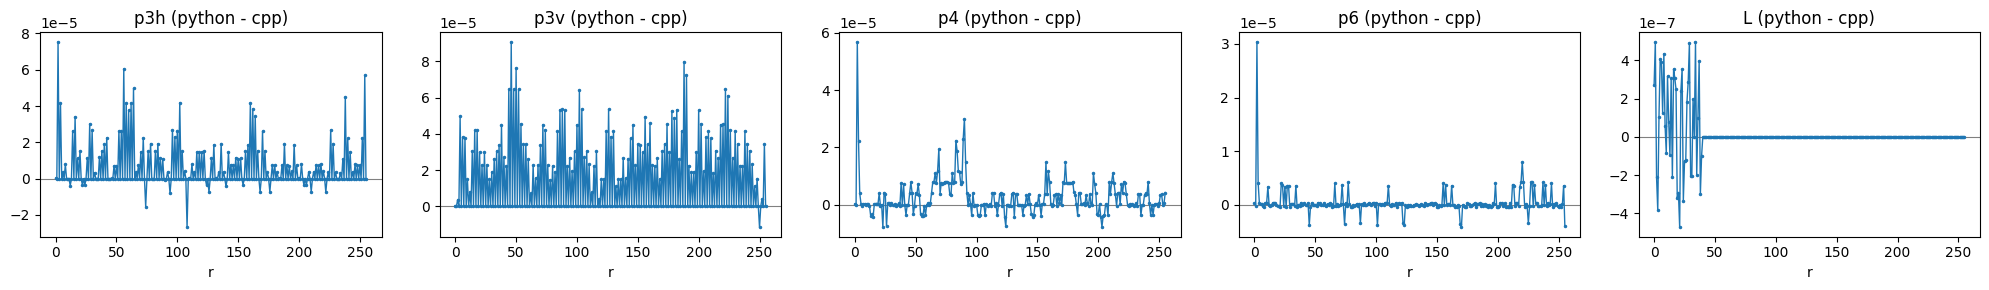

In [10]:
fig, axes = plt.subplots(1, len(POLYTOPES), figsize=(4 * len(POLYTOPES), 3), squeeze=False)
axes = axes[0]

for ax, name in zip(axes, POLYTOPES):
    if name not in cpp_raw:
        continue
    r = py_raw[name][:, 0]
    diff = py_raw[name][:, 1] - cpp_raw[name][:, 1]
    ax.axhline(0, color="gray", lw=0.8)
    ax.plot(r, diff, ".-", ms=3, lw=1)
    ax.set_title(f"{name} (python - cpp)")
    ax.set_xlabel("r")

plt.tight_layout()
plt.show()

# Verify the two-point cluster function C2 (no GooseEYE)

There's no C++/GooseEYE reference to compare against here (GooseEYE isn't installed - it's not even on PyPI, conda-forge only). So instead of a side-by-side diff like above, this section uses:

1. **Self-consistency checks** on the real test image (things that must be true regardless of what a reference implementation would say, e.g. `C2(0)` must equal the porosity).
2. **A visual check** of the cluster label map itself.
3. **Synthetic images with an exact, hand-computable expected answer** - these are stronger than eyeballing a real image, because we know precisely what the correct output is, not just what looks plausible.

If you later get GooseEYE running (e.g. via conda) somewhere, the natural next step is to add a real `GooseEYE.clusters()`/`GooseEYE.C2()` comparison cell here, the same way the C++ comparison works above.

In [11]:
from src.micro_gui.analysis.smds import (
    calculate_c2,
    _label_clusters_periodic,
    calculate_s2_periodic,
    scale_c2_by_connectedness,
)

## Check 1: run C2 on the real test image, `C2(0)` must equal the porosity

In [12]:
c2 = calculate_c2(img)
porosity = img.mean()

print(f"C2(0)     = {c2[0]:.6f}")
print(f"porosity  = {porosity:.6f}")
assert np.isclose(c2[0], porosity), "C2(0) must equal the porosity - every foreground pixel is trivially in the same cluster as itself"
print("Check 1 PASSED")

C2(0)     = 0.250420
porosity  = 0.250420
Check 1 PASSED


## Check 2: C2(r) must never exceed S2(r)

"Same cluster" is a strictly stronger condition than "same phase" (every pair in the same cluster is also in the same phase, but not vice versa), so `C2(r) <= S2(r)` must hold at every `r`. If this were ever violated, that would mean the code found *more* same-cluster pairs than same-phase pairs, which is impossible - a solid correctness guardrail.

max(C2 - S2) = 0.0000000000 (must be <= 0)
violations   = 0 (must be 0)
Check 2 PASSED


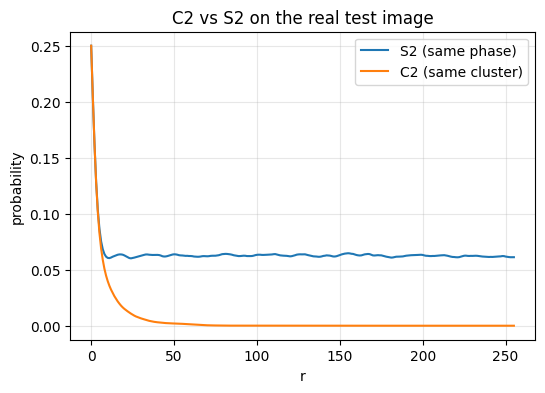

In [13]:
s2_same_conv = calculate_s2_periodic(img)

violations = np.sum(c2 > s2_same_conv + 1e-9)
print(f"max(C2 - S2) = {np.max(c2 - s2_same_conv):.10f} (must be <= 0)")
print(f"violations   = {violations} (must be 0)")
assert violations == 0
print("Check 2 PASSED")

plt.figure(figsize=(6, 4))
plt.plot(s2_same_conv, label="S2 (same phase)")
plt.plot(c2, label="C2 (same cluster)")
plt.xlabel("r")
plt.ylabel("probability")
plt.title("C2 vs S2 on the real test image")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Check 3: visualize the cluster label map

A purely visual sanity check - each connected pore should get one solid color, matching the white regions in the original binary image, with no obviously wrong behavior (e.g. everything as one color, or a random speckle with no relation to the real pore shapes). Label IDs are randomly shuffled before plotting so that spatially close clusters (which tend to have close IDs, since flood fill visits the image roughly top-to-bottom) don't end up as similar colors.

n_clusters found in the real image: 893


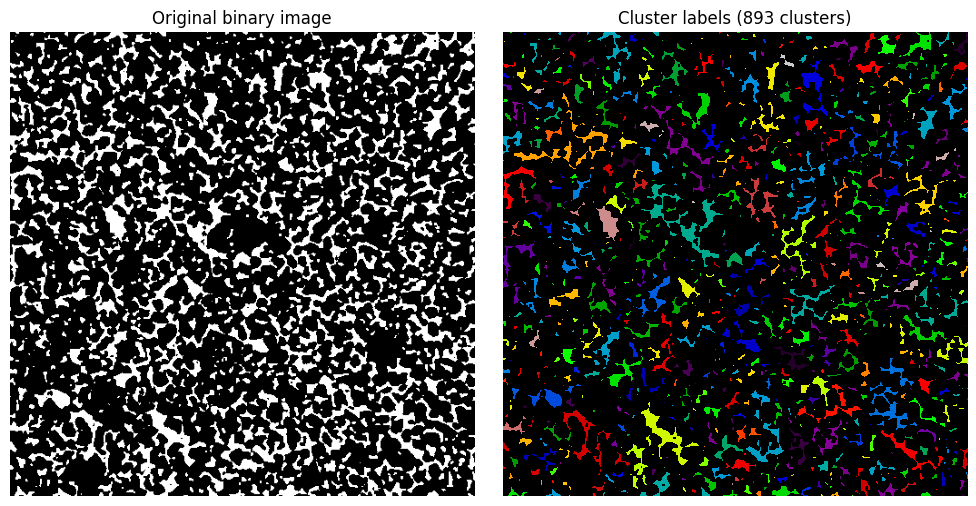

In [14]:
labels = _label_clusters_periodic(img)
n_clusters = int(labels.max())
print(f"n_clusters found in the real image: {n_clusters}")

rng = np.random.RandomState(0)
shuffled_ids = rng.permutation(n_clusters) + 1  # keep 0 (background) fixed, shuffle 1..n
remap = np.zeros(n_clusters + 1, dtype=np.int64)
remap[1:] = shuffled_ids
display_labels = remap[labels]

display_labels_masked = np.ma.masked_where(display_labels == 0, display_labels)
cmap = plt.cm.nipy_spectral.copy()
cmap.set_bad(color="black")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Original binary image")
axes[0].axis("off")
axes[1].imshow(display_labels_masked, cmap=cmap)
axes[1].set_title(f"Cluster labels ({n_clusters} clusters)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Check 4: synthetic images with an exact expected answer

Each of these has a hand-computable correct result, so these are closer to unit tests than to visual sanity checks.

In [15]:
# Test 1: a single filled blob, away from the edges. With only one cluster, "same cluster"
# and "same phase" are identical conditions for every foreground pixel, so C2 must equal
# the (same-convention) periodic S2 EXACTLY - not just approximately.
synthetic1 = np.zeros((64, 64), dtype=np.uint8)
synthetic1[10:30, 10:30] = 1

n_clusters1 = int(_label_clusters_periodic(synthetic1).max())
c2_1 = calculate_c2(synthetic1)
s2_1 = calculate_s2_periodic(synthetic1)

print(f"Test 1 (single blob): n_clusters = {n_clusters1} (expected 1)")
print(f"Test 1 (single blob): max|C2 - S2| = {np.max(np.abs(c2_1 - s2_1)):.10f} (expected 0)")
assert n_clusters1 == 1
assert np.allclose(c2_1, s2_1, atol=1e-9)
print("Test 1 PASSED\n")


# Test 2: fully foreground image. Periodic + 4-connected means every pixel connects to
# every other pixel through the wraparound, so this must be exactly ONE cluster, and every
# pair of points (all of them foreground) is in that cluster, so C2(r) must be 1.0 everywhere.
synthetic2 = np.ones((64, 64), dtype=np.uint8)
n_clusters2 = int(_label_clusters_periodic(synthetic2).max())
c2_2 = calculate_c2(synthetic2)

print(f"Test 2 (fully foreground): n_clusters = {n_clusters2} (expected 1)")
print(f"Test 2 (fully foreground): C2 range = [{c2_2.min():.6f}, {c2_2.max():.6f}] (expected [1.0, 1.0])")
assert n_clusters2 == 1
assert np.allclose(c2_2, 1.0)
print("Test 2 PASSED\n")


# Test 3: fully background image. No foreground pixels at all, so there are no clusters and
# no same-cluster pairs - C2(r) must be exactly 0.0 everywhere.
synthetic3 = np.zeros((64, 64), dtype=np.uint8)
n_clusters3 = int(_label_clusters_periodic(synthetic3).max())
c2_3 = calculate_c2(synthetic3)

print(f"Test 3 (fully background): n_clusters = {n_clusters3} (expected 0)")
print(f"Test 3 (fully background): C2 range = [{c2_3.min():.6f}, {c2_3.max():.6f}] (expected [0.0, 0.0])")
assert n_clusters3 == 0
assert np.allclose(c2_3, 0.0)
print("Test 3 PASSED\n")


# Test 4: this is the important one for periodicity specifically. Two single-pixel-wide
# foreground columns, at column 0 and at the LAST column, with nothing connecting them
# through the interior. They are only adjacent to each other THROUGH the periodic wrap.
# If periodic boundaries were implemented correctly, this must be exactly ONE cluster. If
# periodicity were broken (e.g. accidentally non-periodic), this would show up as 2 clusters.
synthetic4 = np.zeros((64, 64), dtype=np.uint8)
synthetic4[:, 0] = 1
synthetic4[:, -1] = 1
n_clusters4 = int(_label_clusters_periodic(synthetic4).max())

print(f"Test 4 (periodic-wrap merge): n_clusters = {n_clusters4} (expected 1 - only merges if wraparound works)")
assert n_clusters4 == 1
print("Test 4 PASSED\n")


# Test 5: two blobs, far apart and far from the edges (no periodicity involved at all).
# This checks the flip side of Test 4 - that unrelated clusters are correctly kept SEPARATE,
# not spuriously merged.
synthetic5 = np.zeros((64, 64), dtype=np.uint8)
synthetic5[5:15, 5:15] = 1
synthetic5[40:50, 40:50] = 1
n_clusters5 = int(_label_clusters_periodic(synthetic5).max())

print(f"Test 5 (two separate blobs): n_clusters = {n_clusters5} (expected 2)")
assert n_clusters5 == 2
print("Test 5 PASSED")

Test 1 (single blob): n_clusters = 1 (expected 1)
Test 1 (single blob): max|C2 - S2| = 0.0000000000 (expected 0)
Test 1 PASSED

Test 2 (fully foreground): n_clusters = 1 (expected 1)
Test 2 (fully foreground): C2 range = [1.000000, 1.000000] (expected [1.0, 1.0])
Test 2 PASSED

Test 3 (fully background): n_clusters = 0 (expected 0)
Test 3 (fully background): C2 range = [0.000000, 0.000000] (expected [0.0, 0.0])
Test 3 PASSED

Test 4 (periodic-wrap merge): n_clusters = 1 (expected 1 - only merges if wraparound works)
Test 4 PASSED

Test 5 (two separate blobs): n_clusters = 2 (expected 2)
Test 5 PASSED


## Plot: C2 raw and scaled, on the real test image

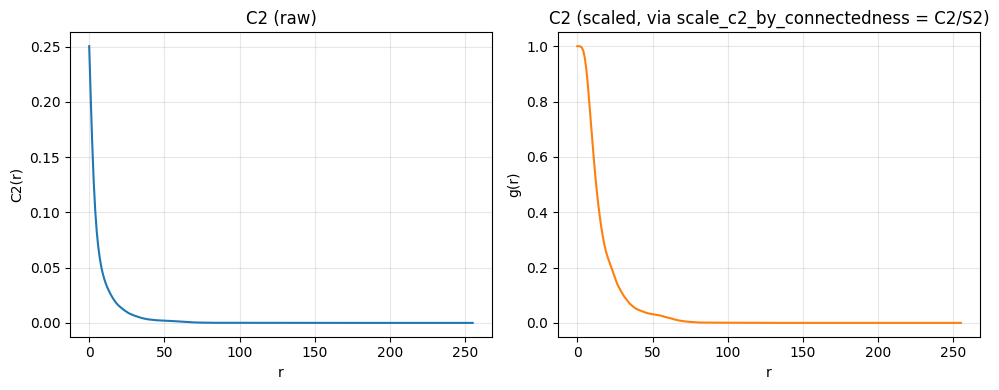

In [16]:
c2_raw_2col = np.column_stack((np.arange(len(c2), dtype=np.float64), c2))
c2_scaled = scale_c2_by_connectedness(c2, s2_same_conv)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(c2_raw_2col[:, 0], c2_raw_2col[:, 1], lw=1.5)
axes[0].set_title("C2 (raw)")
axes[0].set_xlabel("r")
axes[0].set_ylabel("C2(r)")
axes[0].grid(alpha=0.3)

axes[1].plot(c2_raw_2col[:, 0], c2_scaled, lw=1.5, color="tab:orange")
axes[1].set_title("C2 (scaled, via scale_c2_by_connectedness = C2/S2)")
axes[1].set_xlabel("r")
axes[1].set_ylabel("g(r)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# tests in 3D

Same idea as the 2D C2 section above, but for `calculate_c2_3d`/`calculate_s2_periodic_3d` (6-connectivity, periodic in all three dimensions). Uses a 128^3 crop of the real 3D sandstone volume instead of the full 512^3 - the O(n^3) cost of the 3D pair-counting makes the full volume slow for iterative testing (see the timing note in `calculate_c2_3d`'s docstring), while 128^3 is fast enough to re-run interactively and is still a real image, not synthetic data.

Image shape: (512, 512, 512), foreground (pore) fraction: 0.2365
CroppedImage shape: (128, 128, 128), foreground (pore) fraction: 0.2388


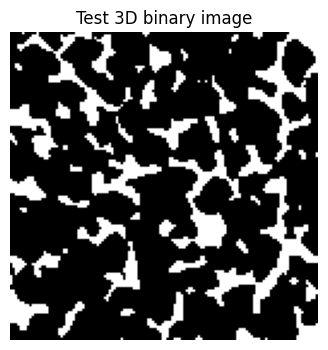

In [17]:
IMAGE_PATH_3D = r"C:\DriveD\GUI_coursera\PythonProject"

img_name_3d = "XCT_11.4um_binary.tif"

img = tifffile.imread(os.path.join(IMAGE_PATH_3D, img_name_3d)).astype(np.uint8)

img_cropped = img[:128, :128, :128]  # crop to a smaller region for faster testing
print(f"Image shape: {img.shape}, foreground (pore) fraction: {img.mean():.4f}")
print(f"CroppedImage shape: {img_cropped.shape}, foreground (pore) fraction: {img_cropped.mean():.4f}")

plt.figure(figsize=(4, 4))
plt.imshow(img_cropped[64], cmap="gray")
plt.title("Test 3D binary image")
plt.axis("off")
plt.show()

In [18]:
import time
from src.micro_gui.analysis.smds import (
    calculate_c2_3d,
    calculate_s2_periodic_3d,
    _label_clusters_periodic_3d,
    scale_c2_by_connectedness,
)

## Run C2 and S2 (periodic, 3D) on the cropped volume

In [19]:
# Using the FULL volume (img), not the 128^3 crop - slower (see timing below) but this is
# what actually answers "is the whole real pore network connected or not".
t0 = time.time()
c2_3d = calculate_c2_3d(img)
t1 = time.time()
print(f"calculate_c2_3d took {t1 - t0:.2f}s ({img.shape[0]}^3 volume, incl. JIT compile on first call)")

t0 = time.time()
s2_3d = calculate_s2_periodic_3d(img)
t1 = time.time()
print(f"calculate_s2_periodic_3d took {t1 - t0:.2f}s ({img.shape[0]}^3 volume, incl. JIT compile on first call)")

calculate_c2_3d took 68.66s (512^3 volume, incl. JIT compile on first call)
calculate_s2_periodic_3d took 70.27s (512^3 volume, incl. JIT compile on first call)


## Check 1: run C2 on the cropped 3D volume, `C2(0)` must equal the porosity

In [20]:
porosity_3d = img.mean()
print(f"C2(0)    = {c2_3d[0]:.6f}")
print(f"porosity = {porosity_3d:.6f}")
assert np.isclose(c2_3d[0], porosity_3d), "C2(0) must equal the porosity of the volume"
print("Check 1 (3D) PASSED")

C2(0)    = 0.236462
porosity = 0.236462
Check 1 (3D) PASSED


## Check 2: C2(r) must never exceed S2(r), in 3D

max(C2 - S2) = 0.0000000000 (must be <= 0 - trivially ~0 at r=0, NOT informative about overall similarity)
violations   = 0 (must be 0)
Check 2 (3D) PASSED

min(C2 - S2)  = -0.00039735  (the single biggest gap)
mean(C2 - S2) = -0.00037329


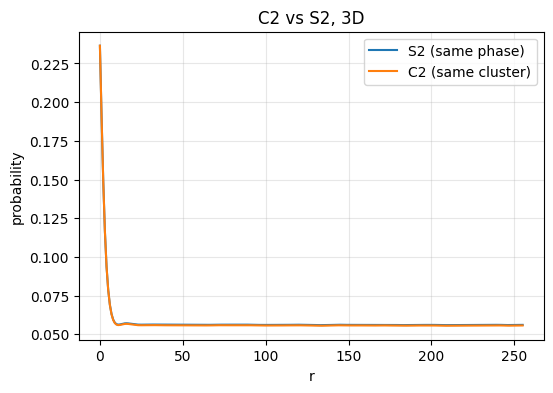

In [21]:
violations_3d = np.sum(c2_3d > s2_3d + 1e-9)
print(f"max(C2 - S2) = {np.max(c2_3d - s2_3d):.10f} (must be <= 0 - trivially ~0 at r=0, NOT informative about overall similarity)")
print(f"violations   = {violations_3d} (must be 0)")
assert violations_3d == 0
print("Check 2 (3D) PASSED")

# The actually-informative numbers for "how different are C2 and S2 overall":
diff_3d = c2_3d - s2_3d
print(f"\nmin(C2 - S2)  = {np.min(diff_3d):.8f}  (the single biggest gap)")
print(f"mean(C2 - S2) = {np.mean(diff_3d):.8f}")

plt.figure(figsize=(6, 4))
plt.plot(s2_3d, label="S2 (same phase)")
plt.plot(c2_3d, label="C2 (same cluster)")
plt.xlabel("r")
plt.ylabel("probability")
plt.title("C2 vs S2, 3D")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Why does C2 look almost identical to S2 here? Checking cluster dominance

If one single cluster holds almost all of the foreground volume, then "same phase" and "same cluster" are nearly the same condition for almost every pair of points, so C2(r) and S2(r) come out nearly equal - not because the code is broken, but because the pore network in this sample is extremely well-connected (a real, physically meaningful property of the rock, expected for a permeable reservoir-rock sample). This checks that directly, rather than just eyeballing the curves.

In [29]:
labels_full = _label_clusters_periodic_3d(img)
n_clusters_full = int(labels_full.max())
sizes_full = np.bincount(labels_full.ravel())[1:]  # drop background (label 0)
sizes_sorted_full = np.sort(sizes_full)[::-1]
total_fg_full = sizes_full.sum()

print(f"n_clusters = {n_clusters_full}")
print(f"total foreground voxels = {total_fg_full}")
print(f"largest cluster = {sizes_sorted_full[0]} voxels ({100 * sizes_sorted_full[0] / total_fg_full:.3f}% of all foreground)")
print(f"top 5 cluster sizes: {sizes_sorted_full[:5]}")
print(f"top 5 as % of foreground: {[round(100 * s / total_fg_full, 4) for s in sizes_sorted_full[:5]]}")
print(f"\nsum of all OTHER (non-largest) clusters combined: {total_fg_full - sizes_sorted_full[0]} voxels "
      f"({100 * (total_fg_full - sizes_sorted_full[0]) / total_fg_full:.4f}% of foreground)")

n_clusters = 12532
total foreground voxels = 31737394
largest cluster = 31625687 voxels (99.648% of all foreground)
top 5 cluster sizes: [31625687      648      537      449      411]
top 5 as % of foreground: [99.648, 0.002, 0.0017, 0.0014, 0.0013]

sum of all OTHER (non-largest) clusters combined: 111707 voxels (0.3520% of foreground)


## Check 3: visualize a slice of the 3D cluster label map

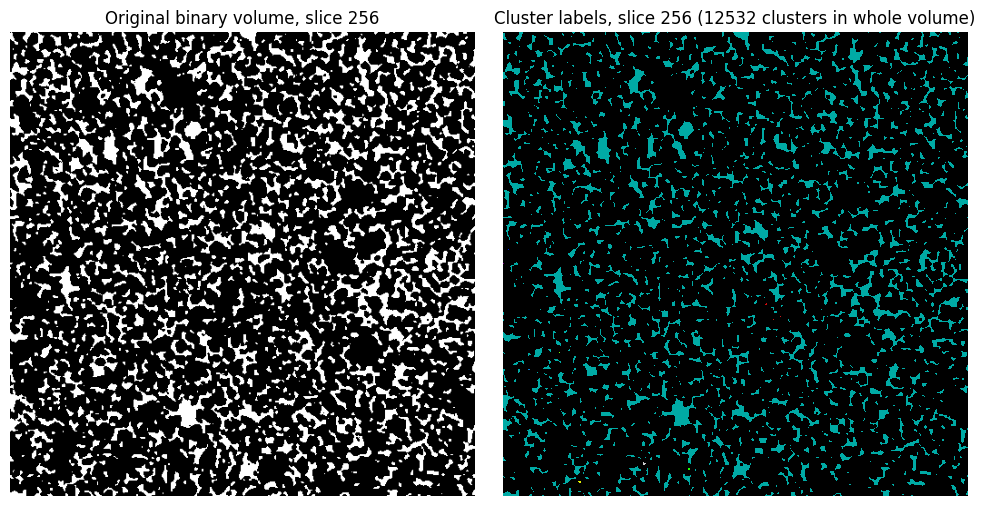

In [30]:
# Reuse labels_full computed above, rather than relabelling - just pick a slice to look at.
mid = img.shape[0] // 2

rng = np.random.RandomState(0)
shuffled_ids = rng.permutation(n_clusters_full) + 1  # keep 0 (background) fixed, shuffle 1..n
remap = np.zeros(n_clusters_full + 1, dtype=np.int64)
remap[1:] = shuffled_ids
display_labels_3d = remap[labels_full]

# Note: a single 3D cluster can pass through a 2D slice in more than one place (e.g. a pore
# that loops back through the same slice plane), so seeing the same color in two disconnected
# spots on this one slice is expected, not a bug - it's still one connected cluster in 3D.
slice_orig = img[mid]
slice_labels = np.ma.masked_where(display_labels_3d[mid] == 0, display_labels_3d[mid])
cmap = plt.cm.nipy_spectral.copy()
cmap.set_bad(color="black")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(slice_orig, cmap="gray")
axes[0].set_title(f"Original binary volume, slice {mid}")
axes[0].axis("off")
axes[1].imshow(slice_labels, cmap=cmap)
axes[1].set_title(f"Cluster labels, slice {mid} ({n_clusters_full} clusters in whole volume)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Check 4: synthetic 3D images with an exact expected answer

3D versions of the same five unit-test-style checks as the 2D section above.

In [31]:
# Test 1: a single filled cube blob, away from the edges. Only one cluster, so "same cluster"
# and "same phase" are identical for every foreground voxel - C2 must equal S2 EXACTLY.
s1 = np.zeros((32, 32, 32), dtype=np.uint8)
s1[5:15, 5:15, 5:15] = 1
n1 = int(_label_clusters_periodic_3d(s1).max())
c2_1 = calculate_c2_3d(s1)
s2_1 = calculate_s2_periodic_3d(s1)
print(f"Test 1 (single blob): n_clusters = {n1} (expected 1)")
print(f"Test 1 (single blob): max|C2-S2| = {np.max(np.abs(c2_1 - s2_1)):.10f} (expected 0)")
assert n1 == 1
assert np.allclose(c2_1, s2_1, atol=1e-9)
print("Test 1 (3D) PASSED\n")


# Test 2: fully foreground volume. Periodic + 6-connected means every voxel connects to
# every other voxel, so exactly 1 cluster, and C2(r) = 1.0 everywhere.
s2v = np.ones((32, 32, 32), dtype=np.uint8)
n2 = int(_label_clusters_periodic_3d(s2v).max())
c2_2 = calculate_c2_3d(s2v)
print(f"Test 2 (fully foreground): n_clusters = {n2} (expected 1)")
print(f"Test 2 (fully foreground): C2 range = [{c2_2.min():.6f}, {c2_2.max():.6f}] (expected [1,1])")
assert n2 == 1
assert np.allclose(c2_2, 1.0)
print("Test 2 (3D) PASSED\n")


# Test 3: fully background volume. No foreground voxels, no clusters, C2(r) = 0.0 everywhere.
s3 = np.zeros((32, 32, 32), dtype=np.uint8)
n3 = int(_label_clusters_periodic_3d(s3).max())
c2_3 = calculate_c2_3d(s3)
print(f"Test 3 (fully background): n_clusters = {n3} (expected 0)")
print(f"Test 3 (fully background): C2 range = [{c2_3.min():.6f}, {c2_3.max():.6f}] (expected [0,0])")
assert n3 == 0
assert np.allclose(c2_3, 0.0)
print("Test 3 (3D) PASSED\n")


# Test 4: periodicity check, 3D version. Two parallel foreground planes at x=0 and x=-1,
# nothing else - only adjacent to each other THROUGH the periodic wrap in x. Must be 1
# cluster if periodic boundaries work correctly; would be 2 if broken.
s4 = np.zeros((32, 32, 32), dtype=np.uint8)
s4[0, :, :] = 1
s4[-1, :, :] = 1
n4 = int(_label_clusters_periodic_3d(s4).max())
print(f"Test 4 (periodic-wrap merge): n_clusters = {n4} (expected 1 - only merges if wraparound works)")
assert n4 == 1
print("Test 4 (3D) PASSED\n")


# Test 5: two separate blobs, far apart and away from the edges (no periodicity involved).
# Checks the flip side of Test 4 - unrelated clusters must stay separate, not merge.
s5 = np.zeros((32, 32, 32), dtype=np.uint8)
s5[2:8, 2:8, 2:8] = 1
s5[20:26, 20:26, 20:26] = 1
n5 = int(_label_clusters_periodic_3d(s5).max())
print(f"Test 5 (two separate blobs): n_clusters = {n5} (expected 2)")
assert n5 == 2
print("Test 5 (3D) PASSED")

Test 1 (single blob): n_clusters = 1 (expected 1)
Test 1 (single blob): max|C2-S2| = 0.0000000000 (expected 0)
Test 1 (3D) PASSED

Test 2 (fully foreground): n_clusters = 1 (expected 1)
Test 2 (fully foreground): C2 range = [1.000000, 1.000000] (expected [1,1])
Test 2 (3D) PASSED

Test 3 (fully background): n_clusters = 0 (expected 0)
Test 3 (fully background): C2 range = [0.000000, 0.000000] (expected [0,0])
Test 3 (3D) PASSED

Test 4 (periodic-wrap merge): n_clusters = 1 (expected 1 - only merges if wraparound works)
Test 4 (3D) PASSED

Test 5 (two separate blobs): n_clusters = 2 (expected 2)
Test 5 (3D) PASSED


## Plot: C2 raw and scaled (C2/S2), 3D cropped volume

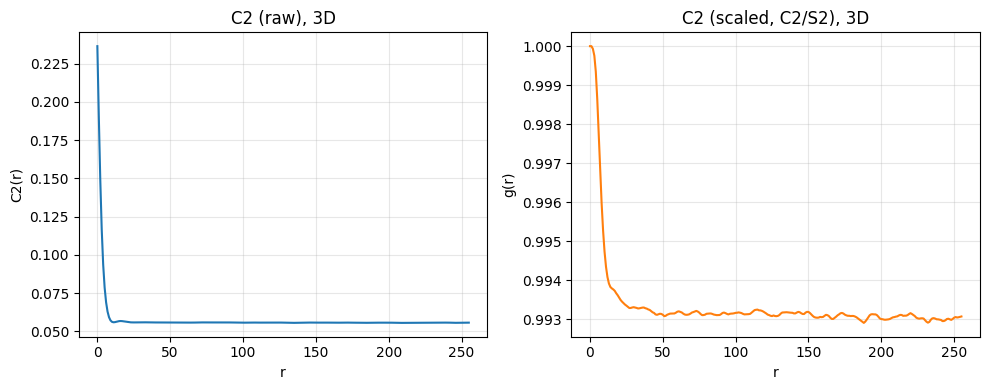

In [32]:
c2_3d_scaled = scale_c2_by_connectedness(c2_3d, s2_3d)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(c2_3d, lw=1.5)
axes[0].set_title("C2 (raw), 3D")
axes[0].set_xlabel("r")
axes[0].set_ylabel("C2(r)")
axes[0].grid(alpha=0.3)

axes[1].plot(c2_3d_scaled, lw=1.5, color="tab:orange")
axes[1].set_title("C2 (scaled, C2/S2), 3D")
axes[1].set_xlabel("r")
axes[1].set_ylabel("g(r)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Control tests: does the code correctly detect genuine fragmentation?

The real rock shows C2 almost equal to S2. Before trusting that as "the rock is just very well-connected" rather than "the code is broken," we need a case where C2 and S2 *must* be very different, and check the code actually produces that.

3D site percolation on a simple-cubic lattice with 6-connectivity has a well-known threshold around `p_c ~ 0.31`: random binary noise **below** that fraction is provably fragmented into many small clusters with no giant cluster spanning the volume; **above** it, one giant cluster dominates. We generate random noise at a volume fraction on each side of that threshold and check that C2 behaves as it must in each case - collapsing toward 0 relative to S2 when genuinely fragmented, and only showing a real gap (not near-total agreement) even when percolating, unless the sample is as exceptionally well-connected as the real rock turned out to be.

In [33]:
def report_fragmentation(img_synth, label, rng):
    labels = _label_clusters_periodic_3d(img_synth)
    n_clusters = int(labels.max())
    sizes = np.bincount(labels.ravel())[1:]
    sizes_sorted = np.sort(sizes)[::-1]
    total_fg = sizes.sum()

    c2 = calculate_c2_3d(img_synth)
    s2 = calculate_s2_periodic_3d(img_synth)
    ratio = scale_c2_by_connectedness(c2, s2)

    print(f"=== {label} (p={img_synth.mean():.3f}) ===")
    print(f"n_clusters = {n_clusters}, largest cluster = {100 * sizes_sorted[0] / total_fg:.2f}% of foreground")
    print(f"C2/S2 ratio range: [{np.nanmin(ratio):.4f}, {np.nanmax(ratio):.4f}]")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(s2, label="S2")
    axes[0].plot(c2, label="C2")
    axes[0].set_title(f"{label}: C2 vs S2")
    axes[0].set_xlabel("r")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[1].plot(ratio, color="tab:orange")
    axes[1].set_title(f"{label}: C2/S2 ratio")
    axes[1].set_xlabel("r")
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return c2, s2, ratio


rng = np.random.RandomState(42)

### Below threshold (p=0.15) - genuinely fragmented, no dominant cluster

=== Fragmented (below percolation threshold) (p=0.149) ===
n_clusters = 74398, largest cluster = 0.03% of foreground
C2/S2 ratio range: [0.0000, 1.0000]


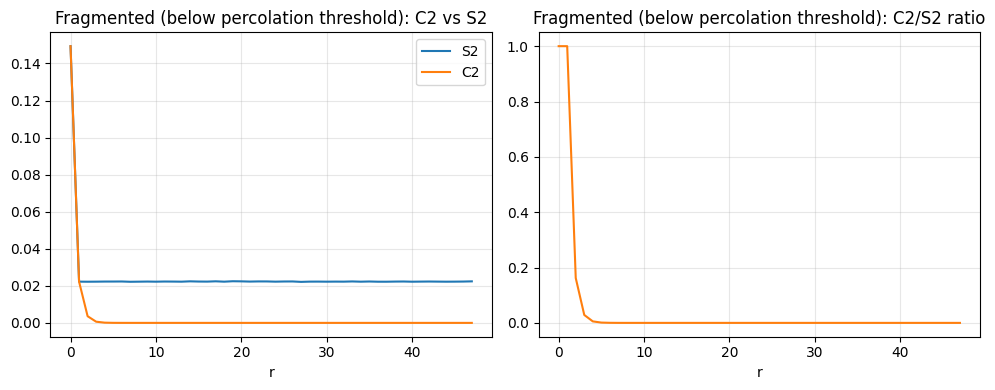

Fragmentation control test PASSED - C2 correctly collapses relative to S2 when the structure is NOT connected


In [34]:
img_fragmented = (rng.random_sample((96, 96, 96)) < 0.15).astype(np.uint8)
c2_frag, s2_frag, ratio_frag = report_fragmentation(img_fragmented, "Fragmented (below percolation threshold)", rng)

# With no dominant cluster, C2 must collapse toward 0 much faster than S2 - the opposite of
# what we saw on the real rock. If this DIDN'T show a big gap, that would mean the C2 code
# itself is broken (always reporting ~S2 regardless of input).
assert np.nanmin(ratio_frag) < 0.1, "expected C2/S2 to collapse well below 0.1 for a genuinely fragmented structure"
print("Fragmentation control test PASSED - C2 correctly collapses relative to S2 when the structure is NOT connected")

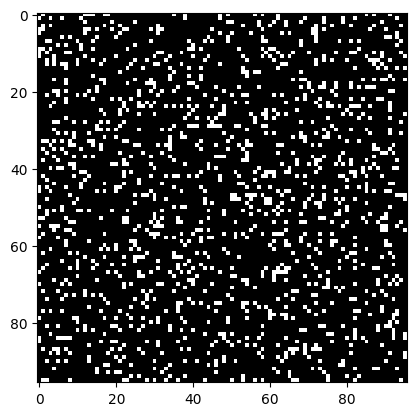

In [35]:
plt.figure()
plt.imshow(img_fragmented[48], cmap="gray")
plt.show()

### Above threshold (p=0.45) - percolating, but not as extreme as the real rock

=== Percolating (above threshold) (p=0.451) ===
n_clusters = 13265, largest cluster = 95.55% of foreground
C2/S2 ratio range: [0.9123, 1.0000]


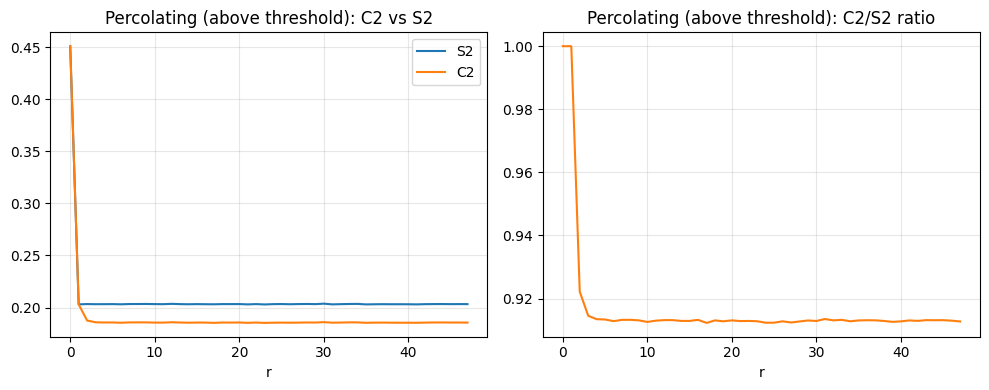


For comparison:
  fragmented (p=0.15) C2/S2 min: 0.0000
  percolating (p=0.45) C2/S2 min: 0.9123
  real rock (full 512^3) C2/S2 min: 0.9929


In [36]:
img_percolating = (rng.random_sample((96, 96, 96)) < 0.45).astype(np.uint8)
c2_perc, s2_perc, ratio_perc = report_fragmentation(img_percolating, "Percolating (above threshold)", rng)

# This one DOES have a dominant cluster (comparable in spirit to the real rock), but a
# generic random medium at p=0.45 isn't nearly as extremely connected as the real sandstone
# was (99.6%) - so it should show a real, visible gap (a few percent to ~10%), clearly
# distinguishable from both the near-1.0 real-rock ratio and the near-0 fragmented ratio.
print(f"\nFor comparison:")
print(f"  fragmented (p=0.15) C2/S2 min: {np.nanmin(ratio_frag):.4f}")
print(f"  percolating (p=0.45) C2/S2 min: {np.nanmin(ratio_perc):.4f}")
print(f"  real rock (full 512^3) C2/S2 min: {np.nanmin(c2_3d / s2_3d):.4f}")

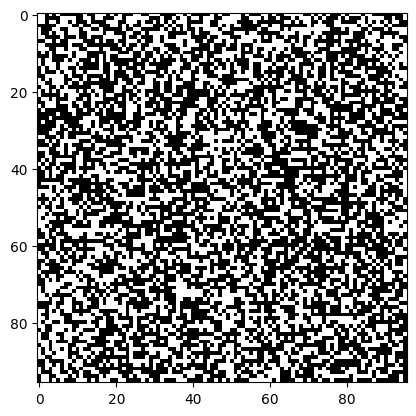

In [37]:
plt.figure()
plt.imshow(img_percolating[48], cmap="gray")
plt.show()